<a href="https://colab.research.google.com/github/minahilzameer50-web/e-plantShopping/blob/main/Diabetes_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

In [ ]:
df = pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

print("\nStatistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nOutcome Distribution:")
print(df['Outcome'].value_counts())

Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.00000

In [ ]:
invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[invalid_cols] = df[invalid_cols].replace(0, np.nan)

print(df.isnull().sum())

for col in invalid_cols:
    df[col] = df[col].fillna(df[col].median())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


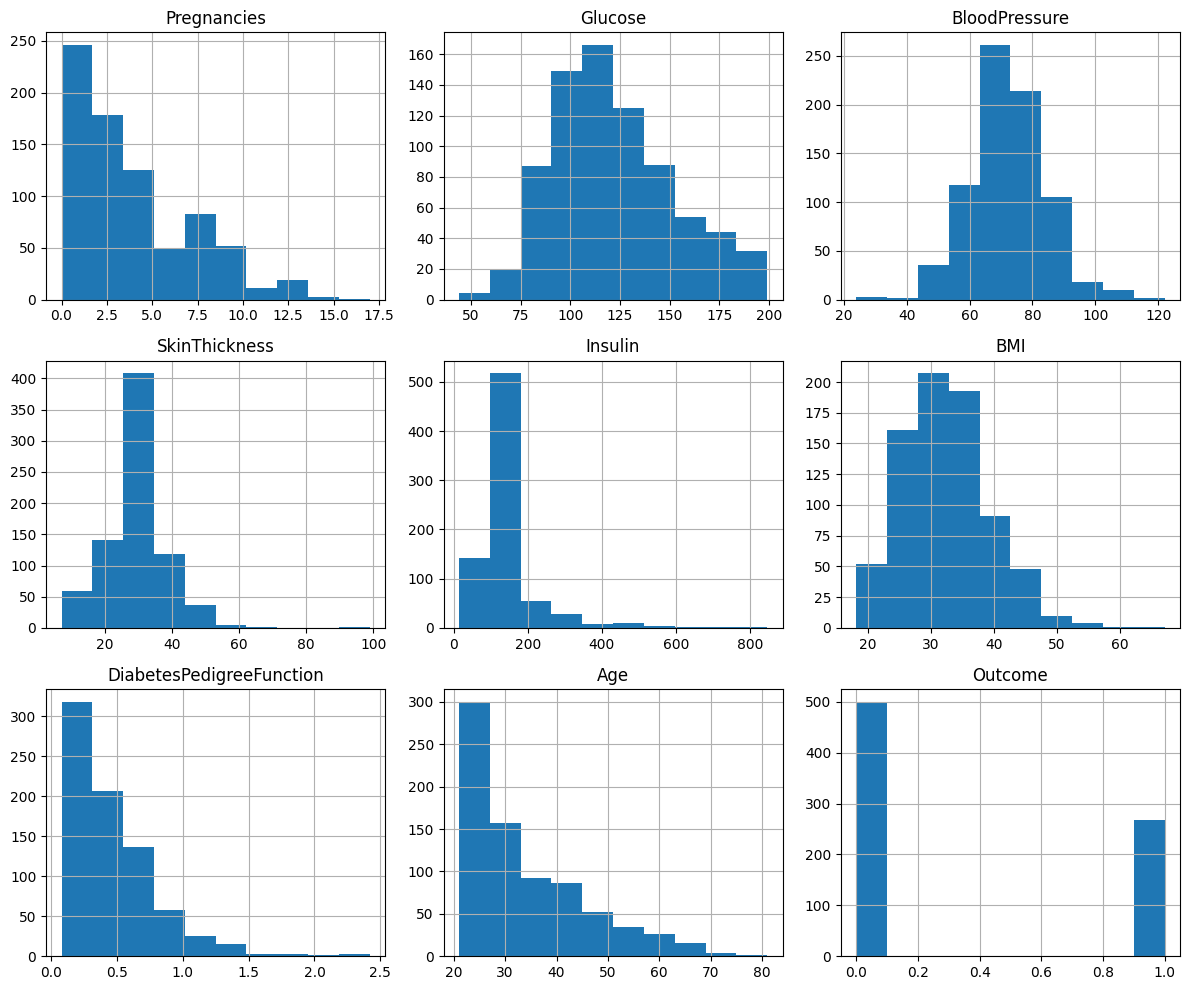

In [ ]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

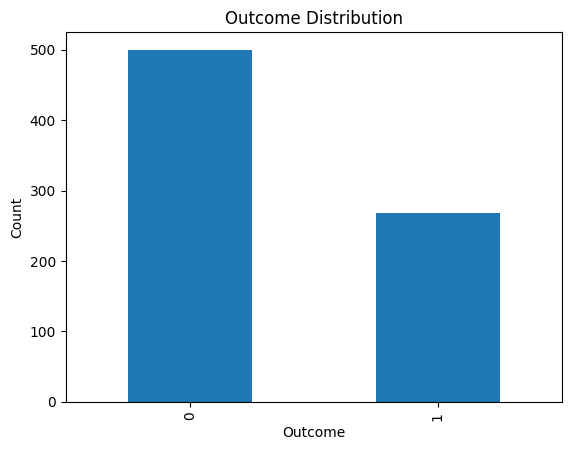

In [ ]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

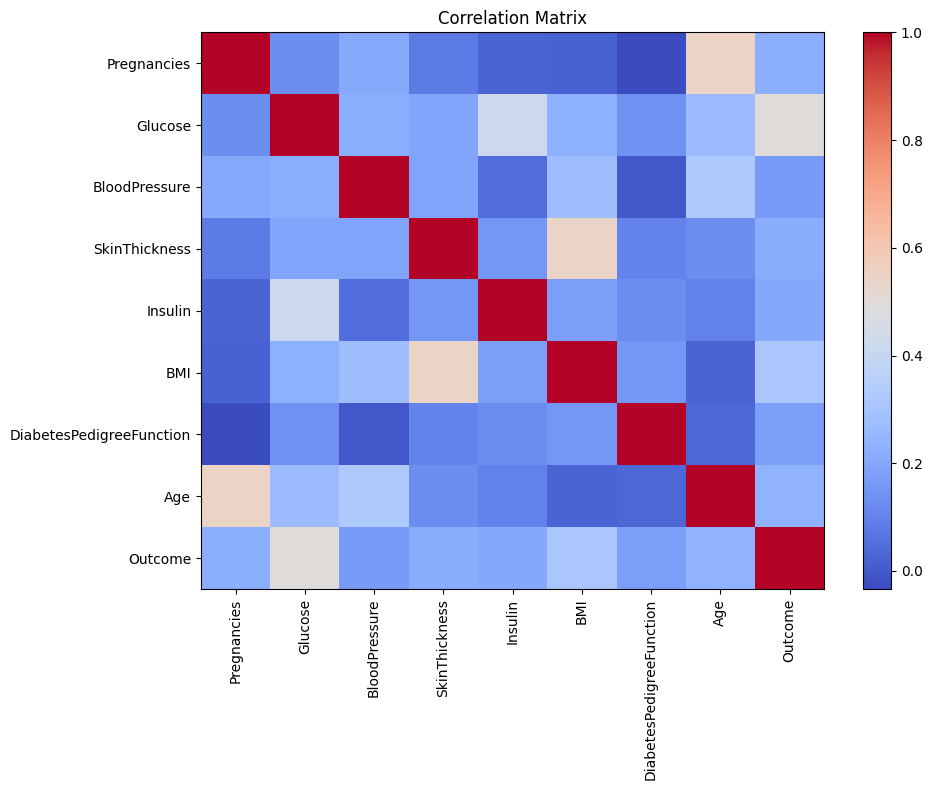

In [ ]:
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

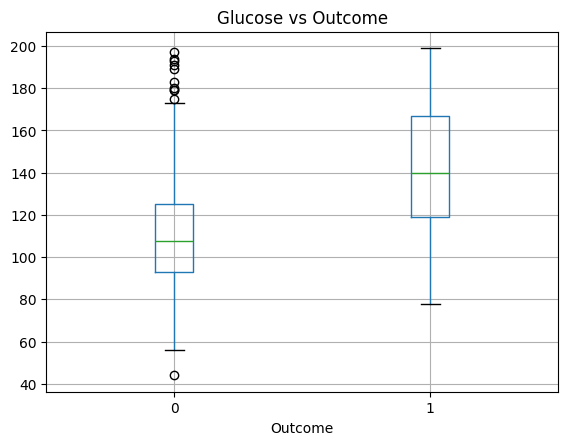

In [ ]:
df.boxplot(column='Glucose', by='Outcome')
plt.title('Glucose vs Outcome')
plt.suptitle('')
plt.show()

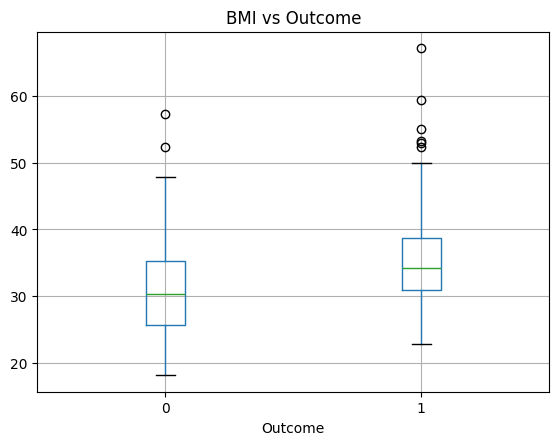

In [ ]:
df.boxplot(column='BMI', by='Outcome')
plt.title('BMI vs Outcome')
plt.suptitle('')
plt.show()

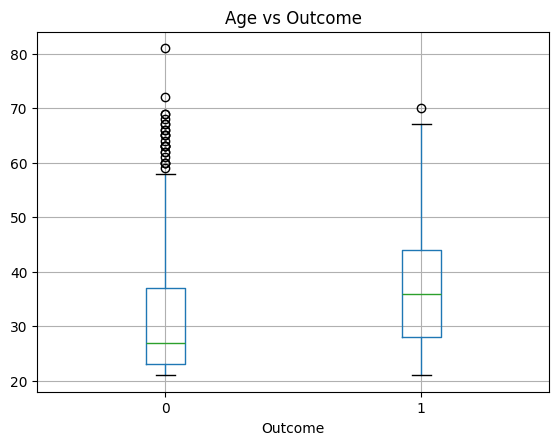

In [ ]:
df.boxplot(column='Age', by='Outcome')
plt.title('Age vs Outcome')
plt.suptitle('')
plt.show()

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7857142857142857
Precision: 0.6981132075471698
Recall: 0.6851851851851852
F1 Score: 0.6915887850467289


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

[[84 16]
 [17 37]]
TN: 84
FP: 16
FN: 17
TP: 37


In [ ]:
mpg = pd.read_csv('/content/auto-mpg.csv')
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [ ]:
print(mpg.shape)
print(mpg.dtypes)
print(mpg.describe(include='all'))
print(mpg.isnull().sum())
print("Duplicates:", mpg.duplicated().sum())

(398, 7)
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model-year        int64
dtype: object
              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  396.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.189394  2970.424623   
std      7.815984    1.701004    104.269838   38.402030   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   75.000000  2223.750000   
50%     23.000000    4.000000    148.500000   92.000000  2803.500000   
75%     29.000000    8.000000    262.000000  125.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model-year  
count    398.000000  398.000000  
mean      15.568090   76.010050  
std        2.757689    3.697627  
min        8.000000   70

In [ ]:
mpg['horsepower'] = pd.to_numeric(mpg['horsepower'], errors='coerce')

mpg['horsepower'] = mpg['horsepower'].fillna(
    mpg['horsepower'].median()
)

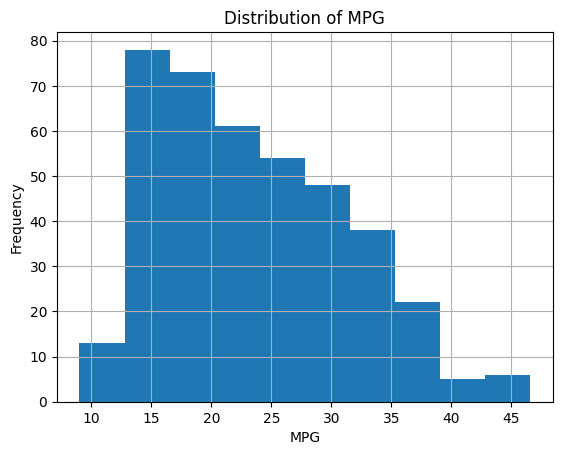

In [ ]:
# EDA - MPG Distribution
mpg['mpg'].hist()
plt.title('Distribution of MPG')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.show()

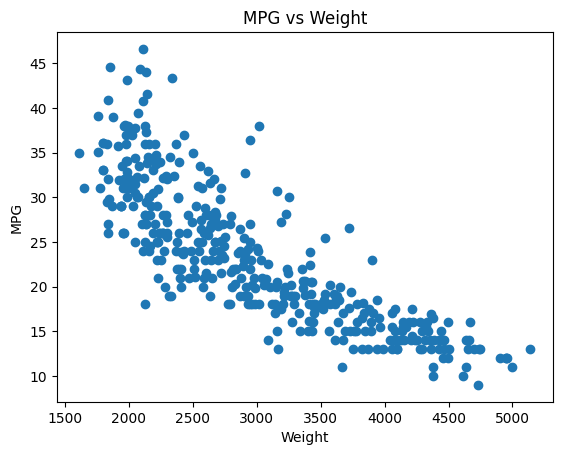

In [ ]:
# MPG vs Weight
plt.scatter(mpg['weight'], mpg['mpg'])
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('MPG vs Weight')
plt.show()

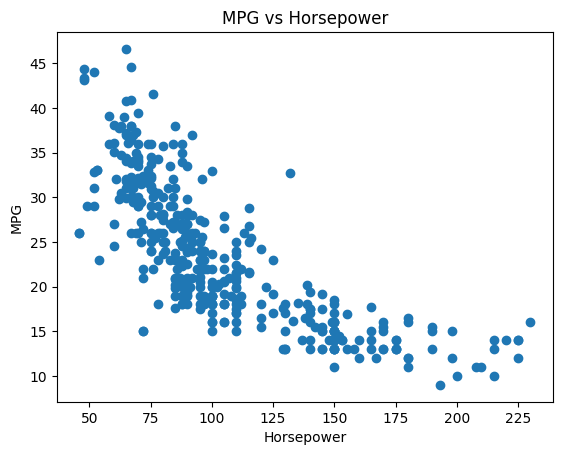

In [ ]:
# MPG vs Horsepower
plt.scatter(mpg['horsepower'], mpg['mpg'])
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower')
plt.show()

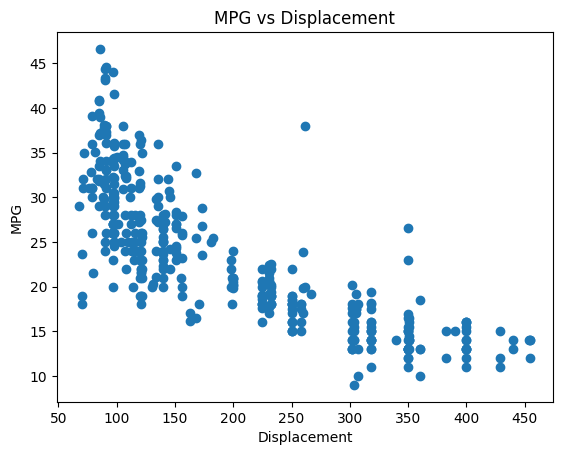

In [ ]:
# MPG vs Displacement
plt.scatter(mpg['displacement'], mpg['mpg'])
plt.xlabel('Displacement')
plt.ylabel('MPG')
plt.title('MPG vs Displacement')
plt.show()

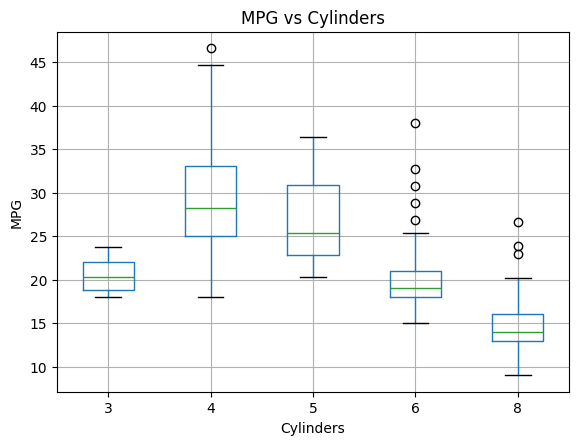

In [ ]:
# MPG vs Cylinders
mpg.boxplot(column='mpg', by='cylinders')
plt.title('MPG vs Cylinders')
plt.suptitle('')
plt.xlabel('Cylinders')
plt.ylabel('MPG')
plt.show()

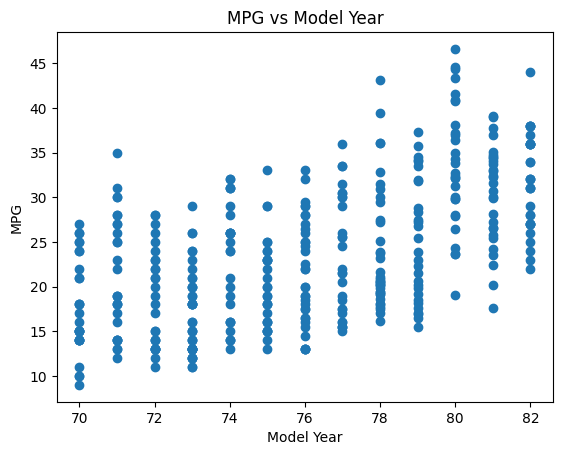

In [ ]:
# MPG vs Model Year
plt.scatter(mpg['model-year'], mpg['mpg'])
plt.xlabel('Model Year')
plt.ylabel('MPG')
plt.title('MPG vs Model Year')
plt.show()

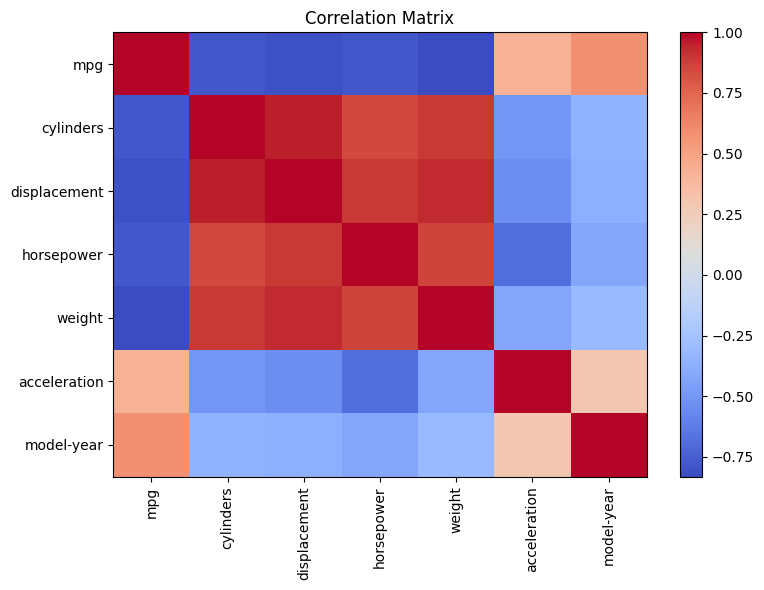

In [ ]:
corr = mpg.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
X = mpg.drop('mpg', axis=1)
y = mpg['mpg']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
reg = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

reg.fit(X_train_scaled, y_train)

y_pred_reg = reg.predict(X_test_scaled)

In [ ]:
mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_reg)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.095258580979169
MSE: 7.716016294011373
RMSE: 2.7777718218045506
R2 Score: 0.8564901124967677


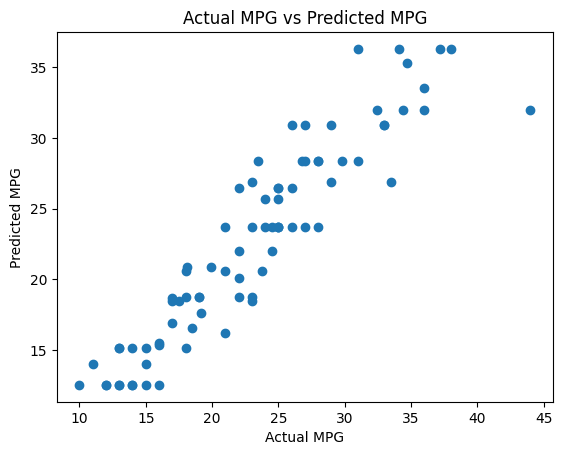

In [ ]:
plt.scatter(y_test, y_pred_reg)

plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual MPG vs Predicted MPG')

plt.show()